In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from ultralytics import YOLO

In [3]:
mobilenet_model = tf.keras.models.load_model(
    "../models/mobilenetv2.keras"
)

print("MobileNetV2 loaded successfully")

MobileNetV2 loaded successfully


In [4]:
yolo_model = YOLO(
    "../notebooks/runs/detect/train-2/weights/best.pt"
)

print("YOLO model loaded successfully")

YOLO model loaded successfully


True Class: couch


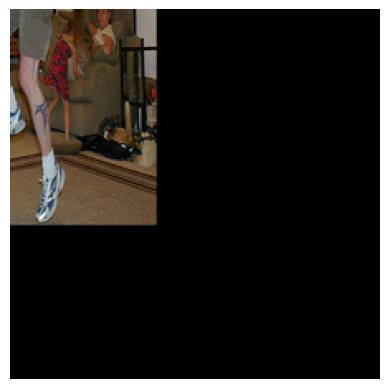

In [5]:
classification_dir = "../smartvision_dataset/classification/test"

classes = os.listdir(classification_dir)

selected_class = random.choice(classes)

image_file = random.choice(
    os.listdir(
        os.path.join(classification_dir, selected_class)
    )
)

image_path = os.path.join(
    classification_dir,
    selected_class,
    image_file
)

print("True Class:", selected_class)

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
img = Image.open(image_path)

img = img.resize((224,224))

img_array = np.array(img)/255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = mobilenet_model.predict(img_array)

predicted_class = np.argmax(prediction)

classification_dir = "../smartvision_dataset/classification/train"

class_names = sorted(
    os.listdir(classification_dir)
)

print("Classes:", class_names)

print(
    "Predicted Class:",
    class_names[predicted_class]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Classes: ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'truck']
Predicted Class: bottle


In [11]:
predicted_class = np.argmax(prediction)

print(
    "Predicted Class:",
    class_names[predicted_class]
)

Predicted Class: bottle


In [12]:
classification_dir = "../smartvision_dataset/classification/train"

class_names = sorted(
    [d for d in os.listdir(classification_dir)
     if os.path.isdir(os.path.join(classification_dir, d))]
)

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 25
['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'truck']


In [13]:
prediction = mobilenet_model.predict(img_array)

predicted_class = np.argmax(prediction)

print("True Class:", selected_class)
print("Predicted Class:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
True Class: couch
Predicted Class: bottle


In [14]:
detection_dir = "../smartvision_dataset/detection/images"

sample_image = random.choice(
    os.listdir(detection_dir)
)

sample_path = os.path.join(
    detection_dir,
    sample_image
)

print(sample_path)

../smartvision_dataset/detection/images\image_000192.jpg


In [15]:
results = yolo_model.predict(
    sample_path,
    conf=0.25,
    save=False
)

results[0].plot()


image 1/1 C:\Users\Home\SmartVision_AI\notebooks\..\smartvision_dataset\detection\images\image_000192.jpg: 288x416 1 car, 2 airplanes, 111.7ms
Speed: 15.6ms preprocess, 111.7ms inference, 5.9ms postprocess per image at shape (1, 3, 288, 416)


array([[[104,  31,  17],
        [104,  31,  17],
        [104,  31,  17],
        ...,
        [104,  31,  17],
        [104,  31,  17],
        [104,  31,  17]],

       [[104,  31,  17],
        [104,  31,  17],
        [104,  31,  17],
        ...,
        [104,  31,  17],
        [104,  31,  17],
        [104,  31,  17]],

       [[104,  31,  17],
        [104,  31,  17],
        [104,  31,  17],
        ...,
        [104,  31,  17],
        [104,  31,  17],
        [104,  31,  17]],

       ...,

       [[104,  31,  17],
        [104,  31,  17],
        [163, 150, 149],
        ...,
        [104,  31,  17],
        [104,  31,  17],
        [104,  31,  17]],

       [[104,  31,  17],
        [104,  31,  17],
        [173, 152, 148],
        ...,
        [104,  31,  17],
        [104,  31,  17],
        [104,  31,  17]],

       [[104,  31,  17],
        [104,  31,  17],
        [104,  31,  17],
        ...,
        [104,  31,  17],
        [104,  31,  17],
        [104,  31,  17]]

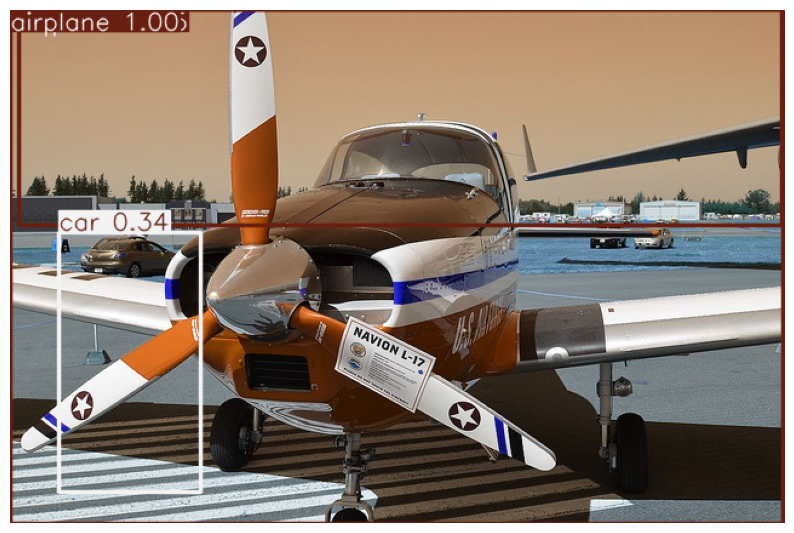

In [16]:
plt.figure(figsize=(10,8))
plt.imshow(results[0].plot())
plt.axis("off")
plt.show()